<a href="https://colab.research.google.com/github/Bhavithra15/data-analytics-and-data-science/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [6]:
df = pd.read_csv('data.csv')

In [7]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [8]:
df.shape

(4600, 18)

In [9]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [10]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [12]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.nunique().sort_values()

,0
country,1
waterfront,2
condition,5
view,5
floors,6
bedrooms,10
bathrooms,26
city,44
yr_renovated,60
date,70


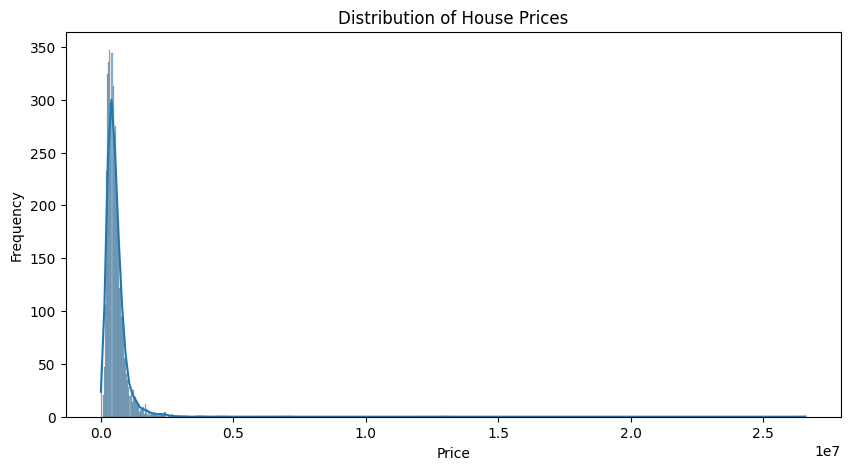

In [15]:
#Target Variable Analysis
plt.figure(figsize=(10, 5))

sns.histplot(df['price'], kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

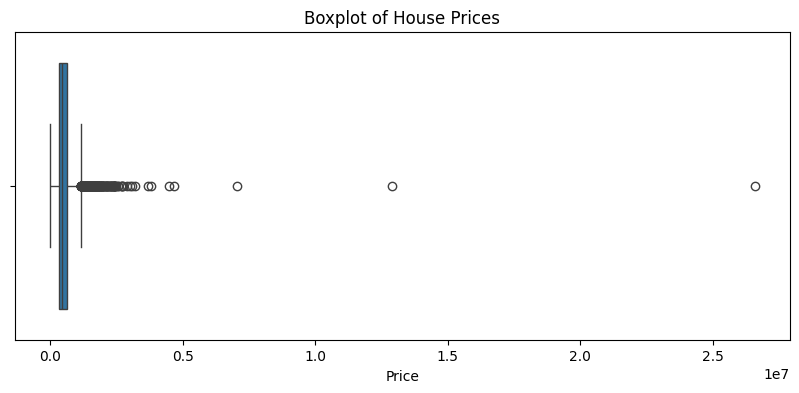

In [16]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['price'])

plt.title('Boxplot of House Prices')
plt.xlabel('Price')

plt.show()

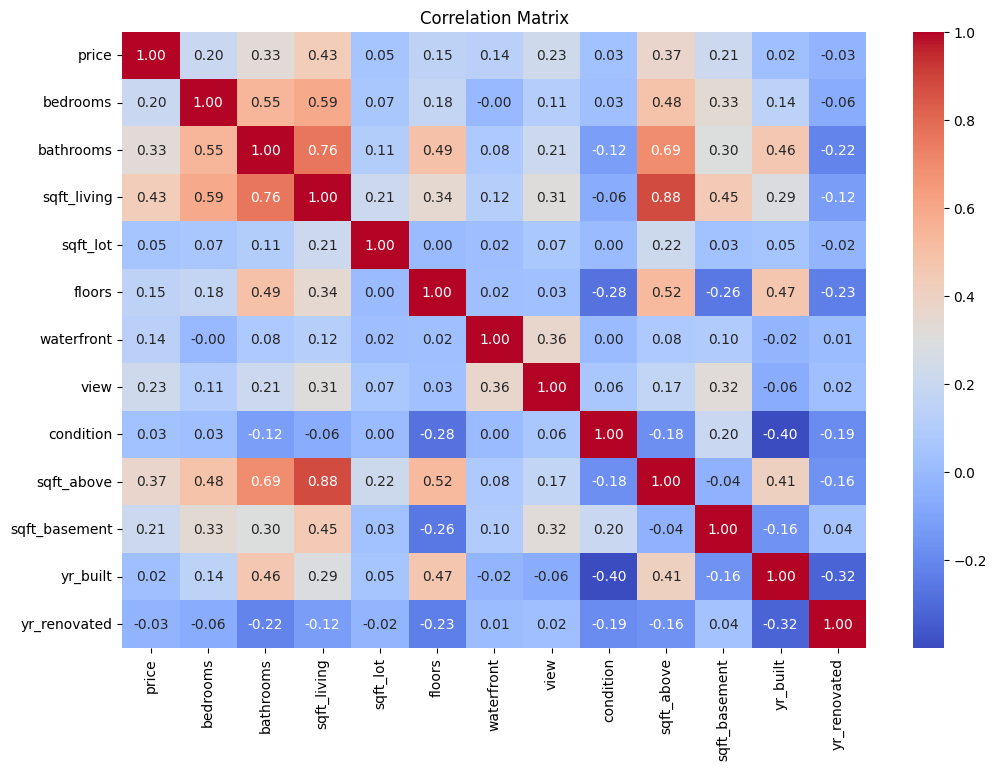

In [19]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

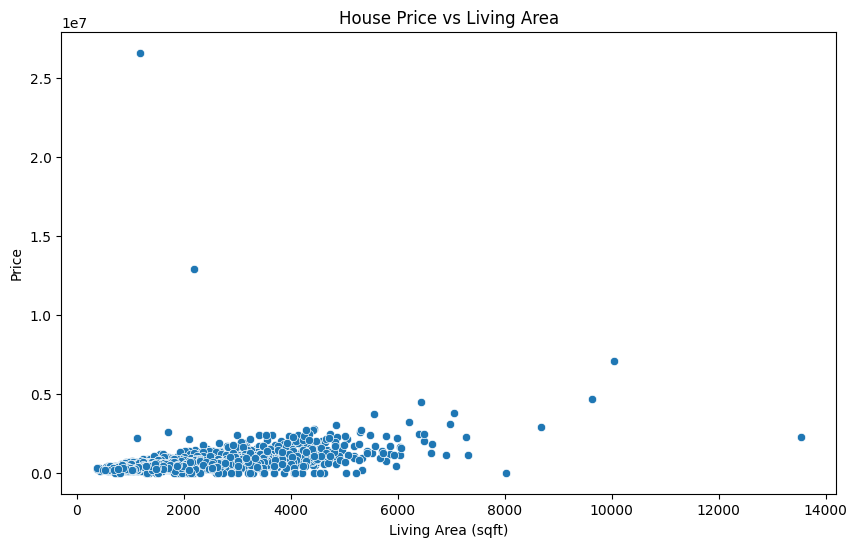

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price'
)

plt.title('House Price vs Living Area')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price')

plt.show()

In [21]:
#Check invalid values
print("Price <= 0:", (df['price'] <= 0).sum())
print("Bedrooms <= 0:", (df['bedrooms'] <= 0).sum())
print("Bathrooms <= 0:", (df['bathrooms'] <= 0).sum())
print("Sqft living <= 0:", (df['sqft_living'] <= 0).sum())
print("Sqft lot <= 0:", (df['sqft_lot'] <= 0).sum())

Price <= 0: 49
Bedrooms <= 0: 2
Bathrooms <= 0: 2
Sqft living <= 0: 0
Sqft lot <= 0: 0


In [26]:
#Remove invalid target values and impossible bedroom/bathroom values
df_clean = df.copy()
df_clean = df_clean[df_clean['price'] > 0]
df_clean = df_clean[
    (df_clean['bedrooms'] > 0) &
    (df_clean['bathrooms'] > 0)
]

In [28]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (4600, 18)
Cleaned shape: (4549, 18)


In [27]:
print("Invalid prices:", (df_clean['price'] <= 0).sum())
print("Invalid bedrooms:", (df_clean['bedrooms'] <= 0).sum())
print("Invalid bathrooms:", (df_clean['bathrooms'] <= 0).sum())

Invalid prices: 0
Invalid bedrooms: 0
Invalid bathrooms: 0


In [30]:
#Feature Engineering
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['sale_year'] = df_clean['date'].dt.year
df_clean['sale_month'] = df_clean['date'].dt.month
df_clean['house_age'] = df_clean['sale_year'] - df_clean['yr_built']
df_clean['is_renovated'] = (df_clean['yr_renovated'] > 0).astype(int)

In [31]:
df_clean[
    ['date', 'yr_built', 'sale_year', 'sale_month',
     'house_age', 'yr_renovated', 'is_renovated']
].head()

,date,yr_built,sale_year,sale_month,house_age,yr_renovated,is_renovated
0,2014-05-02,1955,2014,5,59,2005,1
1,2014-05-02,1921,2014,5,93,0,0
2,2014-05-02,1966,2014,5,48,0,0
3,2014-05-02,1963,2014,5,51,0,0
4,2014-05-02,1976,2014,5,38,1992,1


In [32]:
X = df_clean.drop(
    columns=['price', 'date', 'street', 'country']
)

y = df_clean['price']

Train and Test

In [33]:
#select x and y
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (4549, 18)
y shape: (4549,)

Features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip', 'sale_year', 'sale_month', 'house_age', 'is_renovated']


In [34]:
#train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
#Identify numerical and categorical columns
numeric_features = X_train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'house_age', 'is_renovated']

Categorical features:
['city', 'statezip']


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Linear Regression

In [38]:
#Linear regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [39]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'house_age',
                                                   'is_renovated']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'statezip'])])),
                ('model', LinearRegression())])

In [40]:
y_pred_linear = linear_model.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", mae_linear)
print("MSE:", mse_linear)

Linear Regression
MAE: 143496.9915973601
MSE: 53097161739.29224


DecisionTreeRegressor

In [42]:
from sklearn.tree import DecisionTreeRegressor

In [43]:
decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor(random_state=42))
    ]
)

In [44]:
decision_tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'house_age',
                                                   'is_renovated']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'statezip'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [45]:
y_pred_tree = decision_tree_model.predict(X_test)

In [56]:
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)

print("Decision Tree Regressor")
print("MAE:", mae_tree)
print("MSE:", mse_tree)

Decision Tree Regressor
MAE: 177886.1883929901
MSE: 861273688787.2921


RandomForestRegressor

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [50]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'house_age',
                                                   'is_renovated']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city', 'statezip'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [51]:
y_pred_rf = random_forest_model.predict(X_test)

In [57]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE:", mae_rf)
print("MSE:", mse_rf)

Random Forest Regressor
MAE: 124636.96185582205
MSE: 126813721772.03224


Visualizations

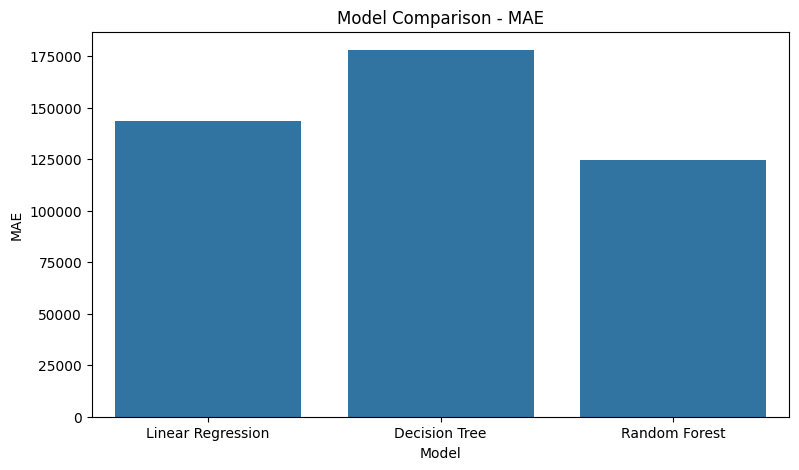

In [59]:
model_names = [
    'Linear Regression',
    'Decision Tree',
    'Random Forest'
]

mae_values = [
    mae_linear,
    mae_tree,
    mae_rf
]

plt.figure(figsize=(9, 5))

sns.barplot(
    x=model_names,
    y=mae_values
)

plt.title('Model Comparison - MAE')
plt.xlabel('Model')
plt.ylabel('MAE')

plt.show()

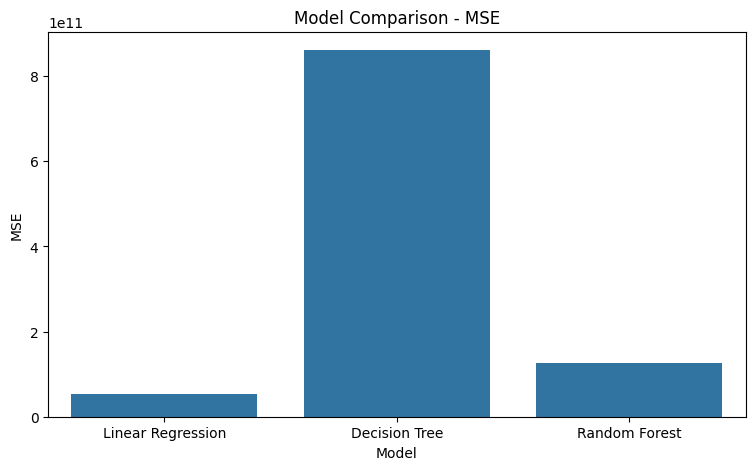

In [61]:
mse_values = [
    mse_linear,
    mse_tree,
    mse_rf
]

plt.figure(figsize=(9, 5))

sns.barplot(
    x=model_names,
    y=mse_values
)

plt.title('Model Comparison - MSE')
plt.xlabel('Model')
plt.ylabel('MSE')

plt.show()

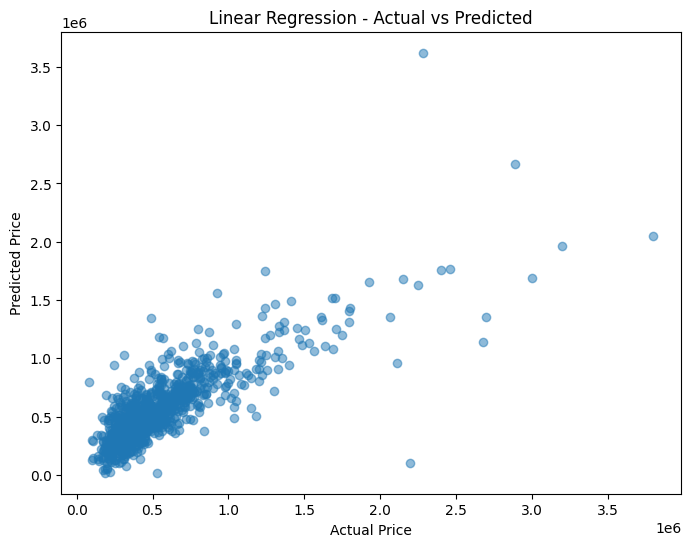

In [62]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression - Actual vs Predicted')

plt.show()

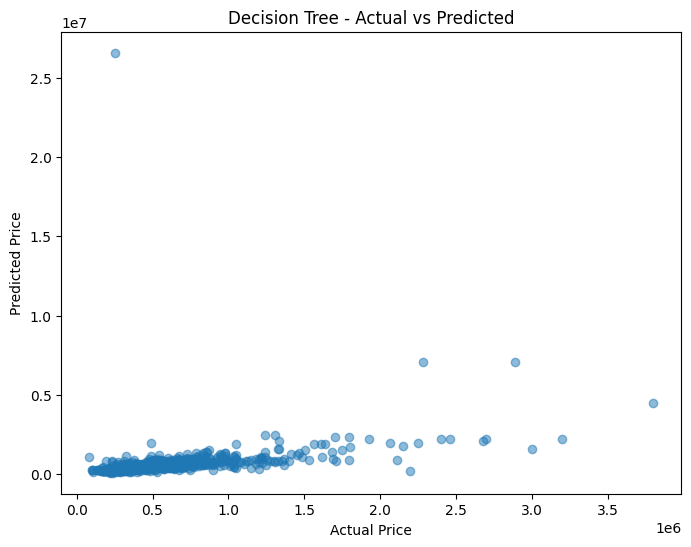

In [63]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tree,
    alpha=0.5
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Decision Tree - Actual vs Predicted')

plt.show()

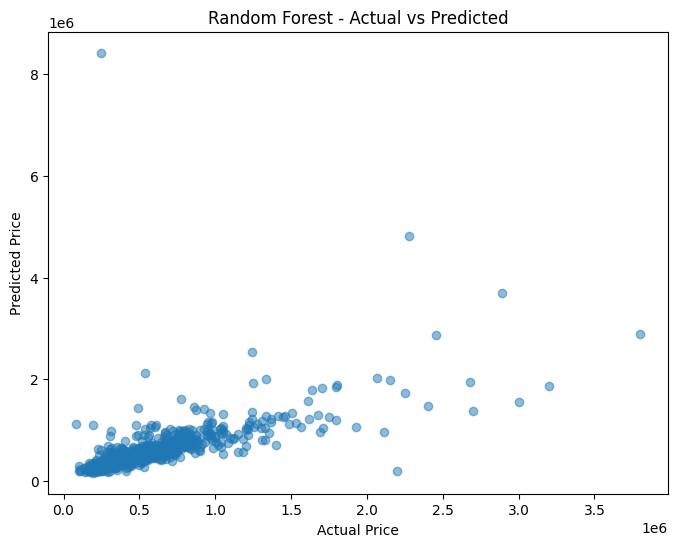

In [64]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest - Actual vs Predicted')

plt.show()

Prediction

In [67]:
new_house = pd.DataFrame({
    "bedrooms": [3],
    "bathrooms": [2],
    "sqft_living": [1800],
    "sqft_lot": [5000],
    "floors": [1],
    "waterfront": [0],
    "view": [0],
    "condition": [3],
    "sqft_above": [1500],
    "sqft_basement": [300],
    "yr_built": [1995],
    "yr_renovated": [0],
    "city": ["Seattle"],
    "statezip": ["WA 98103"],
    "sale_year": [2023],
    "sale_month": [9],
    "house_age": [28],
    "is_renovated": [0]
})

In [71]:
linear_pred = linear_model.predict(new_house)[0]
tree_pred = decision_tree_model.predict(new_house)[0]
rf_pred = random_forest_model.predict(new_house)[0]

print("Predicted House Prices")

print(f"Linear Regression : ${linear_pred:,.2f}")
print(f"Decision Tree     : ${tree_pred:,.2f}")
print(f"Random Forest     : ${rf_pred:,.2f}")

Predicted House Prices
Linear Regression : $509,209.52
Decision Tree     : $436,110.00
Random Forest     : $517,372.14


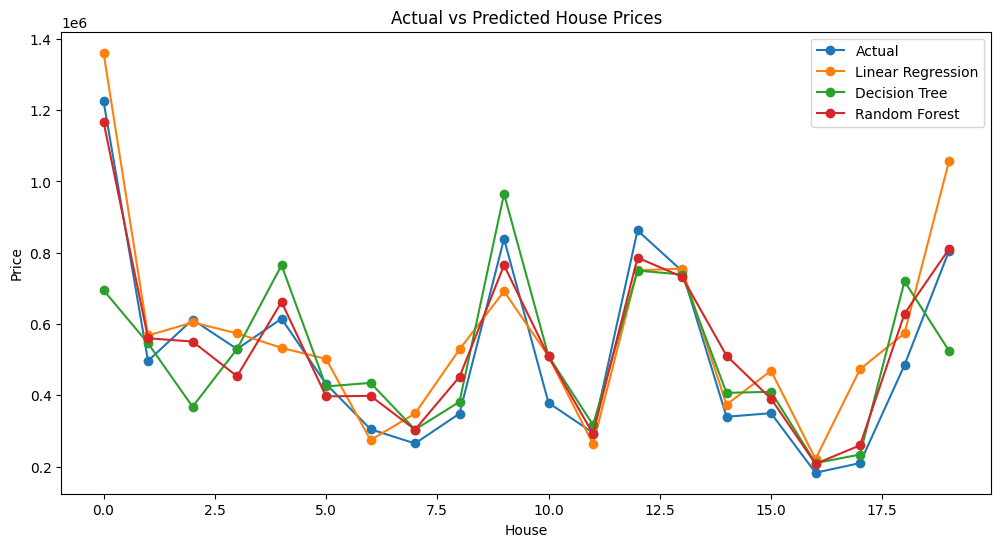

In [74]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Linear Regression': y_pred_linear[:20],
    'Decision Tree': y_pred_tree[:20],
    'Random Forest': y_pred_rf[:20]
})

comparison.plot(
    figsize=(12, 6),
    marker='o'
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("House")
plt.ylabel("Price")
plt.legend()
plt.show()